# Start-of-Month Rebalance: Fixed Ratio Portfolio

The simplest TiPortfolio strategy: a **70% QQQ / 20% BIL / 10% GLD** portfolio
rebalanced at the end of each month.

This notebook demonstrates:
- `Weigh.Ratio` for fixed-weight allocation
- `Signal.Monthly()` for monthly rebalancing
- Multi-backtest comparison with `ti.run(bt1, bt2, bt3)`
- Full results API: summary, plots, trades

**Offline mode**: Uses local CSV files from `tests/data/` — no network required.

In [1]:
from pathlib import Path

import tiportfolio as ti

# Offline CSV data mapping — pre-downloaded YFinance CSVs (2018-2024)
_DATA_DIR = Path("../../tests/data")

CSV_DATA: dict[str, str] = {
    "QQQ": str(_DATA_DIR / "qqq_2018_2024_yf.csv"),
    "BIL": str(_DATA_DIR / "bil_2018_2024_yf.csv"),
    "GLD": str(_DATA_DIR / "gld_2018_2024_yf.csv"),
}

TICKERS = ["QQQ", "BIL", "GLD"]
WEIGHTS = {"QQQ": 0.7, "BIL": 0.2, "GLD": 0.1}
START = "2019-01-01"
END = "2024-12-31"

## 1. Load Data

In [2]:
data = ti.fetch_data(TICKERS, start=START, end=END, csv=CSV_DATA)

# Quick peek at the data shape
for ticker, df in data.items():
    print(f"{ticker}: {df.shape[0]} rows, {df.index[0].date()} \u2192 {df.index[-1].date()}")

QQQ: 1760 rows, 2018-01-02 → 2024-12-30
BIL: 1760 rows, 2018-01-02 → 2024-12-30
GLD: 1760 rows, 2018-01-02 → 2024-12-30


## 2. Define Strategy

The algo stack follows the **Signal \u2192 Select \u2192 Weigh \u2192 Action** pattern:
- **Signal.Monthly()** \u2014 rebalance on the last trading day of each month
- **Select.All()** \u2014 include all tickers in the portfolio
- **Weigh.Ratio()** \u2014 allocate fixed weights (70/20/10)
- **Action.Rebalance()** \u2014 execute trades to match target weights

In [3]:
portfolio = ti.Portfolio(
    "monthly_70_20_10",
    [
        ti.Signal.Monthly(),
        ti.Select.All(),
        ti.Weigh.Ratio(weights=WEIGHTS),
        ti.Action.Rebalance(),
    ],
    TICKERS,
)

result = ti.run(ti.Backtest(portfolio, data))

## 3. Results Overview

In [4]:
result.summary()

,value
sharpe,0.642
calmar,0.546
sortino,0.833
max_drawdown,-0.264
cagr,0.144
risk_free_rate,0.040
total_return,1.559
kelly,3.784
final_value,25588.316
total_fee,0.939


In [5]:
result.plot_interactive()

In [6]:
result.full_summary()

,value
sharpe,0.642
calmar,0.546
sortino,0.833
max_drawdown,-0.264
cagr,0.144
risk_free_rate,0.040
total_return,1.559
kelly,3.784
final_value,25588.316
total_fee,0.939


## 4. Detailed Exploration

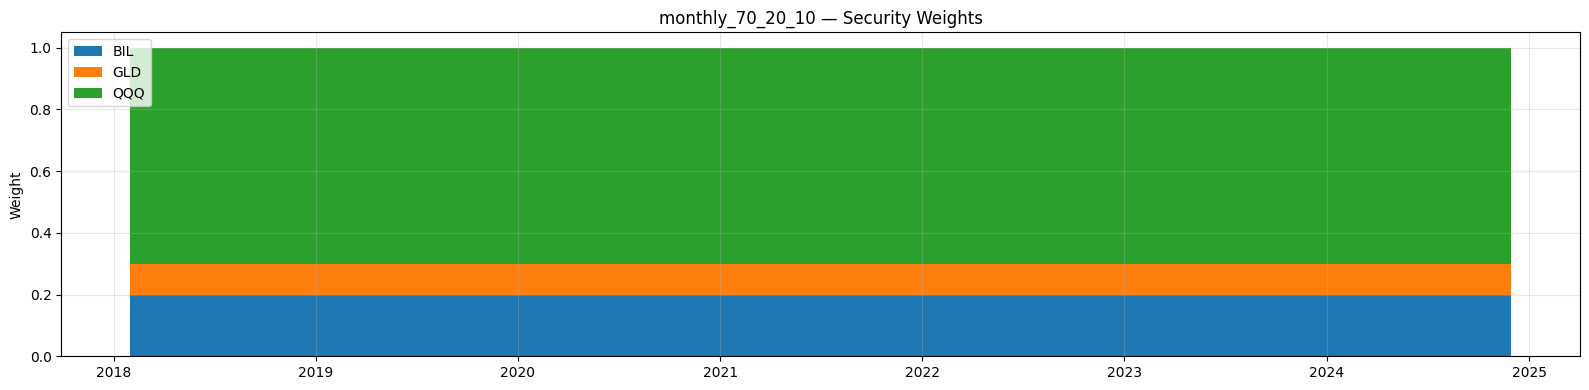

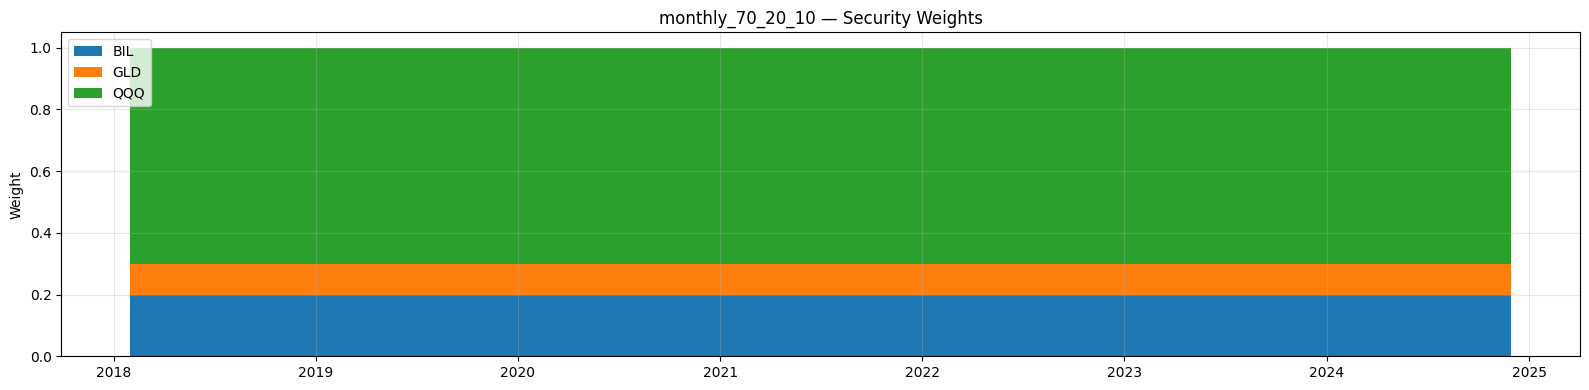

In [7]:
result[0].plot_security_weights()

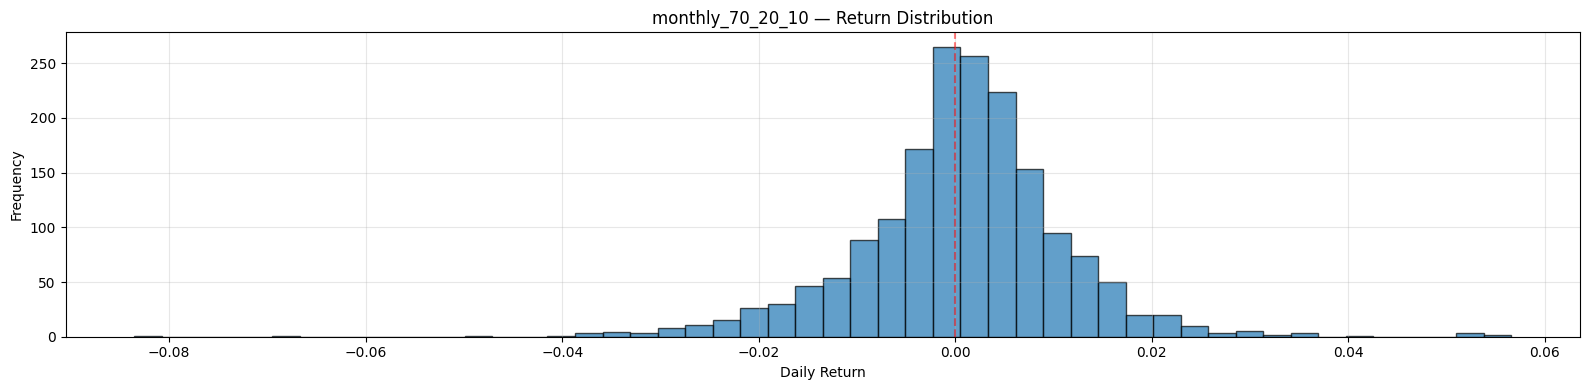

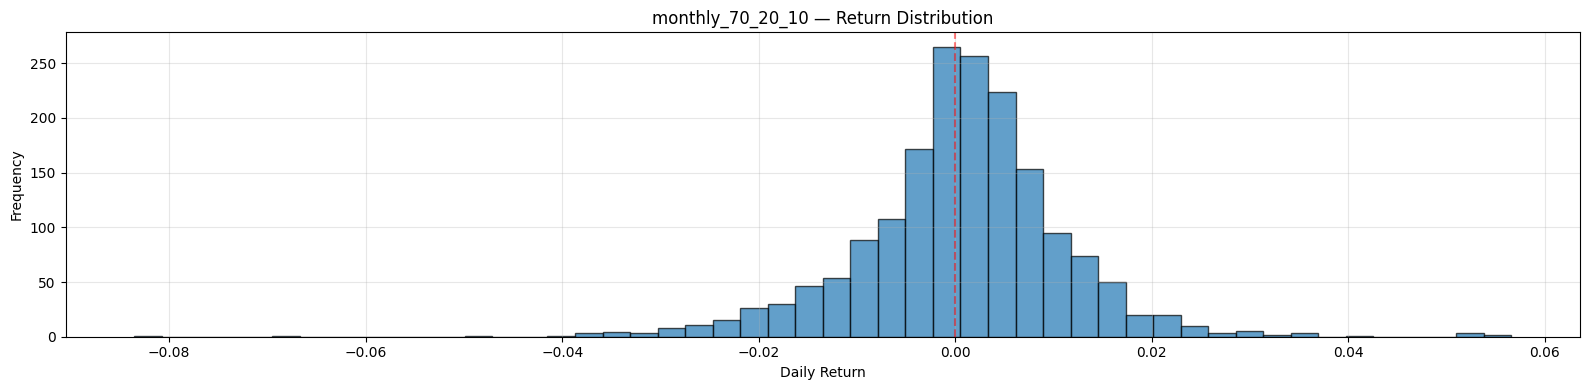

In [8]:
result[0].plot_histogram()

In [9]:
print(f"Total trades: {len(result[0].trades)}")
result[0].trades.sample(5)

Total trades: 249


,date,portfolio,ticker,qty_before,qty_after,delta,price,fee,equity_before,equity_after
189,2023-04-28 04:00:00+00:00,monthly_70_20_10,QQQ,38.404182,38.406627,0.002444,317.337799,0.000009,17411.249203,17411.248848
190,2023-04-28 04:00:00+00:00,monthly_70_20_10,BIL,43.387884,43.453278,0.065394,80.137794,0.000229,17411.249203,17411.248848
191,2023-04-28 04:00:00+00:00,monthly_70_20_10,GLD,9.454296,9.421671,-0.032624,184.800003,0.000114,17411.249203,17411.248848
24,2018-09-28 04:00:00+00:00,monthly_70_20_10,QQQ,41.880444,41.899901,0.019457,177.302582,0.000068,10612.800839,10612.800259
25,2018-09-28 04:00:00+00:00,monthly_70_20_10,BIL,28.126938,28.021539,-0.105399,75.747452,0.000369,10612.800839,10612.800259
0,2018-01-31 05:00:00+00:00,monthly_70_20_10,QQQ,0.000000,43.541692,43.541692,160.765457,0.152396,10000.000000,9999.726795
1,2018-01-31 05:00:00+00:00,monthly_70_20_10,BIL,0.000000,26.682868,26.682868,74.954460,0.093390,10000.000000,9999.726795
2,2018-01-31 05:00:00+00:00,monthly_70_20_10,GLD,0.000000,7.833921,7.833921,127.650002,0.027419,10000.000000,9999.726795
153,2022-04-29 04:00:00+00:00,monthly_70_20_10,QQQ,36.541895,38.178359,1.636464,305.828674,0.005728,16680.052789,16680.028140
154,2022-04-29 04:00:00+00:00,monthly_70_20_10,BIL,47.404210,42.798230,-4.605980,77.947395,0.016121,16680.052789,16680.028140


## 5. Baseline Comparisons

Compare the monthly-rebalanced portfolio against:
1. **QQQ Only** \u2014 100% QQQ, buy once and hold (`Signal.Once()`)
2. **Never Rebalanced** \u2014 same 70/20/10 initial allocation, but never rebalanced (`Signal.Once()`)

In [10]:
# Baseline 1: QQQ only, buy and hold
qqq_only = ti.Portfolio(
    "qqq_only",
    [ti.Signal.Once(), ti.Select.All(), ti.Weigh.Equally(), ti.Action.Rebalance()],
    ["QQQ"],
)

# Baseline 2: Same 70/20/10 allocation, never rebalanced
never_rebal = ti.Portfolio(
    "never_rebalanced",
    [ti.Signal.Once(), ti.Select.All(), ti.Weigh.Ratio(weights=WEIGHTS), ti.Action.Rebalance()],
    TICKERS,
)

## 6. Multi-Backtest Comparison

Run all three strategies together with `ti.run()` for side-by-side analysis:

In [11]:
comparison = ti.run(
    ti.Backtest(portfolio, data),
    ti.Backtest(qqq_only, data),
    ti.Backtest(never_rebal, data),
)

In [12]:
comparison.summary()

,monthly_70_20_10,qqq_only,never_rebalanced
sharpe,0.642,0.684,0.669
calmar,0.546,0.547,0.528
sortino,0.833,0.889,0.875
max_drawdown,-0.264,-0.351,-0.302
cagr,0.144,0.192,0.160
risk_free_rate,0.040,0.040,0.040
total_return,1.559,2.411,1.813
kelly,3.784,2.835,3.558
final_value,25588.316,34106.625,28127.486
total_fee,0.939,0.233,0.284


In [13]:
comparison.plot_interactive()

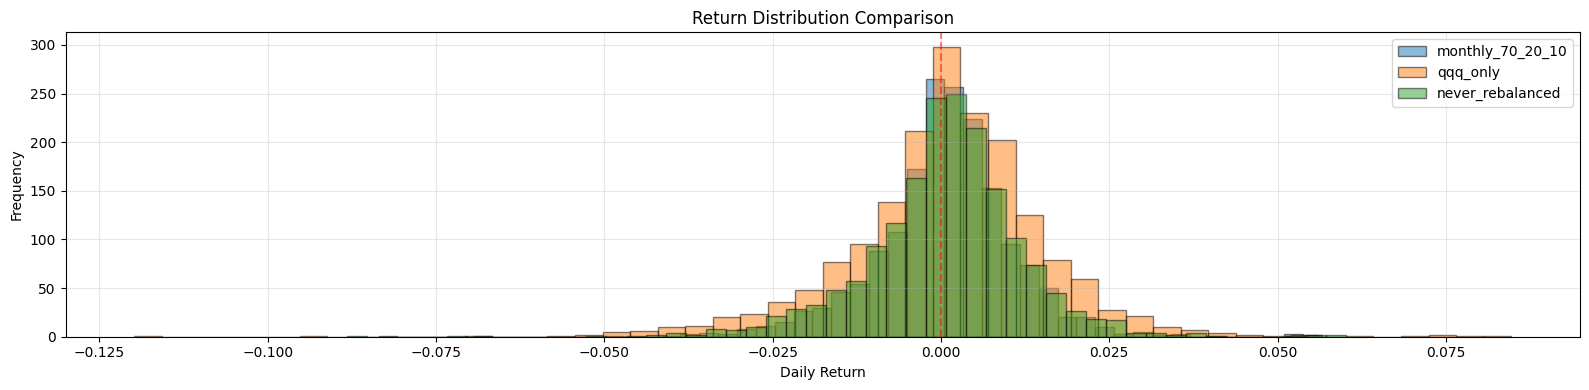

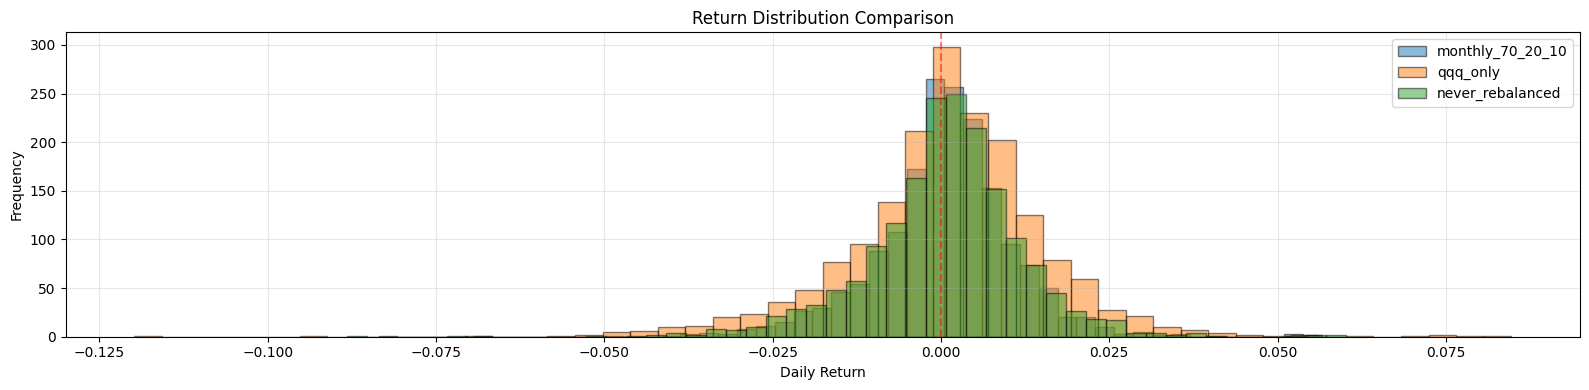

In [14]:
comparison.plot_histogram()